# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is "linear" if it is linear in its parameters. The variables (x's for example) do not necessarily have to be linear, however the parameters or coefficients (b for example) must be linear.
2. The interpretation of the coefficient for a dummy/one-hot-encoded variable depends on whether or not you keep or remove the intercept. With the intercept the coefficient is the difference from the reference category. Without the intercept, the coefficient is the mean of that category. Including an intercept and all the dummy variables resulting in multicolinearity and is an invalid model.
3.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

Average price by neighborhood:
 Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64

Average Review Scores Rating by neighborhood:
 Neighbourhood 
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64


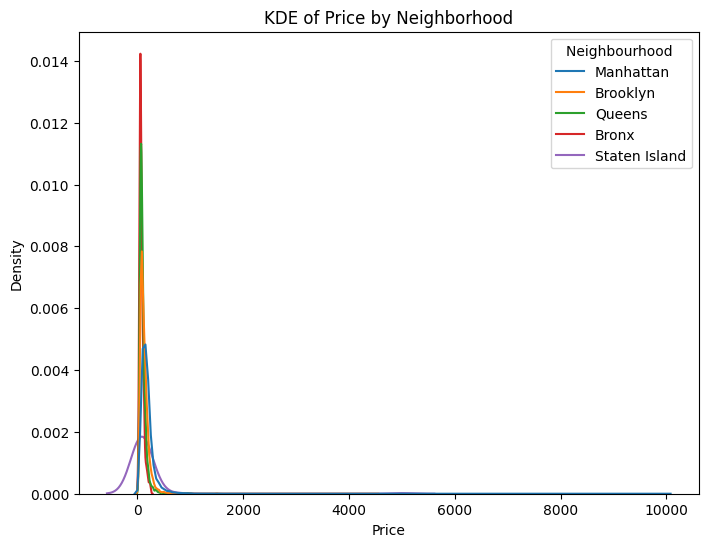

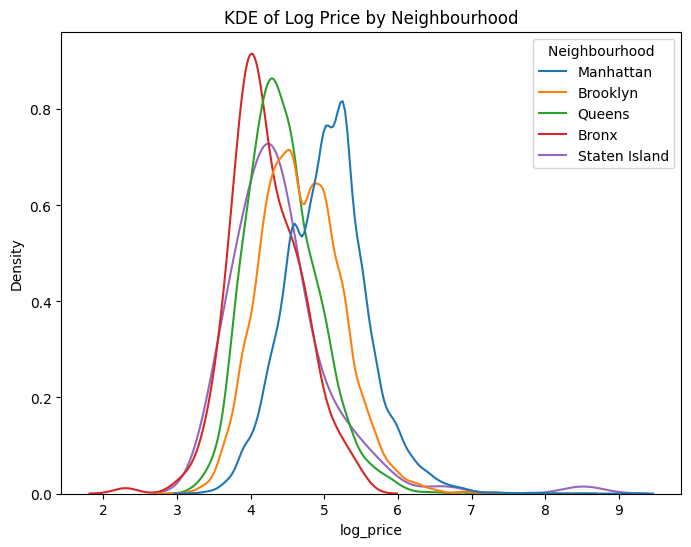


Coefficients (no intercept, neighborhood dummies only):
 Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64

Intercept (baseline neighborhood mean): 75.27649769585331
Coefficients (differences from baseline):
 Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64

Recovered mean prices (should match Part 3):
 Brooklyn         127.747378
Manhattan         75.276498
Queens            96.857233
Staten Island    146.166667
dtype: float64

R² on test set: 0.029117109332052915
RMSE on test set: 194.0474943299375
Coefficient on Review Scores Rating: 1.01609586375163
Most expensive neighborhood (from model): Staten Island
R²: 0.0334068421154583
RMSE: 193.61833164635303
Review Scores coefficient: 1.0022207483987131
Property Type     Condominium
Neighbourhood       Manhattan
Name: 88, dtype: object


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('/content/Q1_clean.csv', low_memory=False)
df.head()
df.Price.describe()

df = df.dropna(subset=['Price', 'Neighbourhood '])
df = df[df['Price'] > 0]

df['log_price'] = np.log(df['Price'])

#average prices and rview scores by neighborhood

price_avg = df.groupby('Neighbourhood ')['Price'].mean()
score_avg = df.groupby('Neighbourhood ')['Review Scores Rating'].mean()

print("Average price by neighborhood:\n", price_avg)
print("\nAverage Review Scores Rating by neighborhood:\n", score_avg)
#create the KDE for price and log price grouped by neighborhood


#plt of KDE of price
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df,
    x='Price',
    hue='Neighbourhood ',
    common_norm=False  # keeps each neighborhood scaled separately
)

plt.title("KDE of Price by Neighborhood")
plt.show()

#plt of KDE of LOG price
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df,
    x='log_price',
    hue='Neighbourhood ',
    common_norm=False  # keeps each neighborhood scaled separately
)

plt.title("KDE of Log Price by Neighbourhood")
plt.show()


# one-hot encode
X_no_intercept = pd.get_dummies(df['Neighbourhood '], dtype=float)
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(X_no_intercept, df['Price'])

# coefficients
coefs_no_intercept = pd.Series(model_no_intercept.coef_, index=X_no_intercept.columns)
print("\nCoefficients (no intercept, neighborhood dummies only):\n", coefs_no_intercept)

#linear regression on coeffcients you dont have!
X_with_intercept = pd.get_dummies(df['Neighbourhood '], drop_first=True)
model_with_intercept = LinearRegression(fit_intercept=True)
model_with_intercept.fit(X_with_intercept, df['Price'])

coefs_with_intercept = pd.Series(model_with_intercept.coef_, index=X_with_intercept.columns)
intercept = model_with_intercept.intercept_

print("\nIntercept (baseline neighborhood mean):", intercept)
print("Coefficients (differences from baseline):\n", coefs_with_intercept)

#  Recover Part 3 coefficients
recovered_means = coefs_with_intercept + intercept
baseline_neigh = df['Neighbourhood '].mode()[0]
recovered_means[baseline_neigh] = intercept
print("\nRecovered mean prices (should match Part 3):\n", recovered_means)

#regression with split
X_full = pd.concat([df[['Review Scores Rating']], X_with_intercept], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=65)

model_full = LinearRegression(fit_intercept=True)
model_full.fit(X_train, y_train)

# Predictions
y_pred = model_full.predict(X_test)

# R² and RMSE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nR² on test set:", r2)
print("RMSE on test set:", rmse)

# Coefficient on Review Scores Rating
coef_dict_full = pd.Series(model_full.coef_, index=X_full.columns)
review_coef = coef_dict_full['Review Scores Rating']
print("Coefficient on Review Scores Rating:", review_coef)

#Intercept = baseline neighborhood mean
baseline_price = model_full.intercept_

# Neighborhood coefficients (differences from baseline)
neigh_coefs = coef_dict_full.drop('Review Scores Rating')

# Compute estimated mean price per neighborhood
neigh_prices = neigh_coefs + baseline_price
neigh_prices[baseline_neigh] = baseline_price  # add baseline

most_expensive_model = neigh_prices.idxmax()
print("Most expensive neighborhood (from model):", most_expensive_model)

#NOW have to run regression of neighborhood, property type, review score on price so o
#must make BOTH neighborhood and property type dummy var

X = pd.get_dummies(df[['Neighbourhood ', 'Property Type']], drop_first=True)
#doesnt need to be dummy but part of regression
X['Review Scores Rating'] = df['Review Scores Rating']
y = df['Price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=65)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions + metrics
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

review_coef = model.coef_[X.columns.get_loc('Review Scores Rating')]

print("R²:", r2)
print("RMSE:", rmse)
print("Review Scores coefficient:", review_coef)

#MOST EXPESNIVE
pred_prices = model.predict(X)
idx_max = np.argmax(pred_prices)

print(df.iloc[idx_max][['Property Type', 'Neighbourhood ']])


1. The most expensive borough on average is Manhattan with an average price of $183.66486 per night.

2. The table of values found in part (1) for the mean pricing of each borough matches almost identically the one-hot-encoded dummy variable weights without the intercept. The regression coefficients are equal to the mean price within each neighborhood. This matches the group averages computed in part 1. When regressing a continuous variable on a single categorical variable **using one-hot encoding without an intercept, each coefficient represents the average of the dependent variable for that category hence the coefficients being identical to the averages from part 1 in the price cateogry by neighborhood.

Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

3. When leaving the intercept in the linear model one of the dummy variables must be dropped otherwise if will cause an invalid modle due to multicollinearity. When one variable is dropped and the intercept is used the coefficient. So in order to create this first the fit intercept must be kpet at false,  **

3.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         976 non-null    int64 
 1   Make               976 non-null    object
 2   Make_Year          976 non-null    int64 
 3   Color              976 non-null    object
 4   Body_Type          976 non-null    object
 5   Mileage_Run        976 non-null    int64 
 6   No_of_Owners       976 non-null    object
 7   Seating_Capacity   976 non-null    int64 
 8   Fuel_Type          976 non-null    object
 9   Transmission       976 non-null    object
 10  Transmission_Type  976 non-null    object
 11  Price              976 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 91.6+ KB


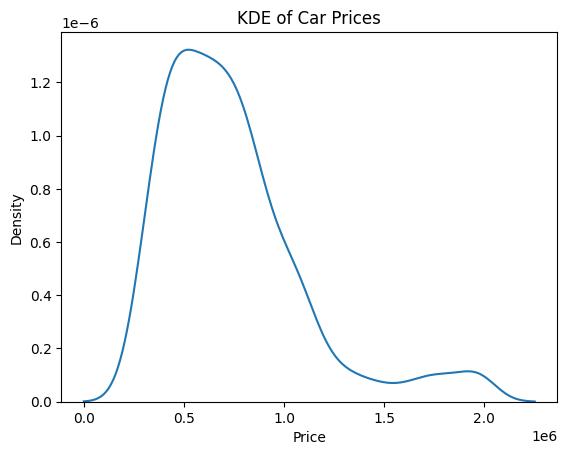

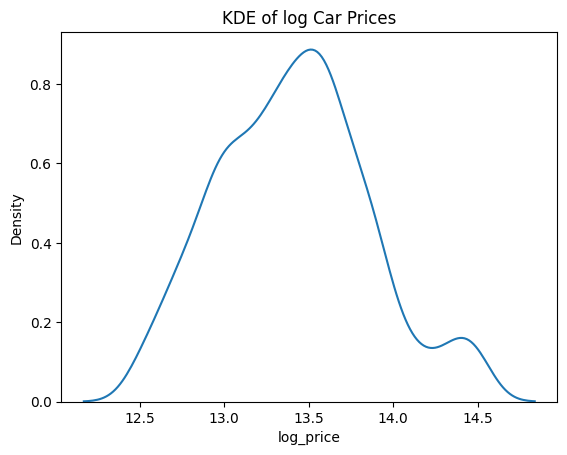

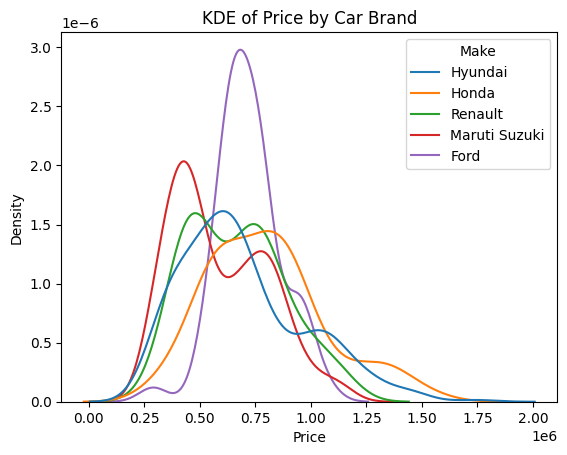

,Price
Make,
MG Motors,1.864429e+06
Kia,1.614750e+06
Jeep,1.499500e+06
Mahindra,1.100167e+06
Tata,1.054935e+06
Skoda,9.437000e+05
Nissan,8.842500e+05
Toyota,8.003400e+05
Honda,7.989726e+05


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/cars_hw.csv', low_memory = False)
df.head()
df.info()
df.describe()

#can see that there are some HEAVY skewed categories so will deal with some

#removing unnamed column bc its not doing anything tohelp us
df=df.drop(columns = ['Unnamed: 0'])

#change # of owners from object of words to numeric
df['No_of_Owners'].unique()
df['No_of_Owners'] = df['No_of_Owners'].map({
    'First': 1,
    'Second': 2,
    'Third' : 3,
     'Fourth & above' : 4
})

#price has a LARGEEE skewed distribution, log transform it for regression (super important)
#winsorize any LARGE outliers
df['Price'] = df['Price'].clip(
    df['Price'].quantile(0.01),
    df['Price'].quantile(0.99)
)
df['log_price'] = np.log(df['Price'])

#do similar thing for mileage
df['log_mileage'] = np.log(df['Mileage_Run'])

#convert age to years
df['Age'] = 2026 - df['Make_Year']
df = df.drop(columns=['Make_Year'])

#summarize price var and make KDE frm it
df['Price'].describe()
sns.kdeplot(data=df, x='Price')
plt.title("KDE of Car Prices")
plt.show()

df['log_price'].describe()
sns.kdeplot(data=df, x='log_price')
plt.title("KDE of log Car Prices")
plt.show()

df.groupby('Make')['Price'].describe()
#KDE grouped by make, but only take top 5 makes because if do ALL of them may be a LOT
top_makes = df['Make'].value_counts().head(5).index

sns.kdeplot(
    data=df[df['Make'].isin(top_makes)],
    x='Price',
    hue='Make',
    common_norm=False
)

plt.title("KDE of Price by Car Brand")
plt.show()

df.groupby('Make')['Price'].mean().sort_values(ascending=False)

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.